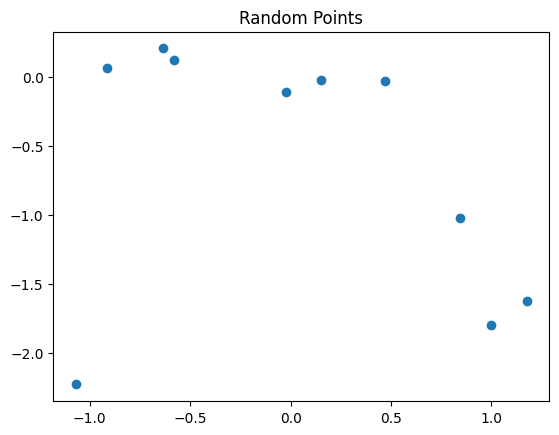

In [213]:
import numpy as np
import matplotlib.pyplot as plt
dof = 10
x = np.random.randn(dof) # np.arange(10)
def make_polynomial(vector, _dof=None):
    if not _dof: _dof = dof
    b = vector.shape[0]
    return np.cumprod(np.concatenate([np.ones((b, 1)), vector.reshape(-1, 1).repeat(_dof-1, axis=1)], axis=1), axis=1)
Z = make_polynomial(x, 10)
d = Z @ np.random.randn(10)
plt.title("Random Points")
plt.scatter(x, d)

1.438949061072323x^0+1.1733673305091443x^1+2.0905684246621843x^2+1.370959027015348x^3+1.0876961089162571x^4+0.4057321922176892x^5+-0.5310391156768655x^6+0.018680452791078297x^7+-1.0529846161854846x^8+-1.6225795328237769x^9
loss(model).mean()=5.2988583531353255


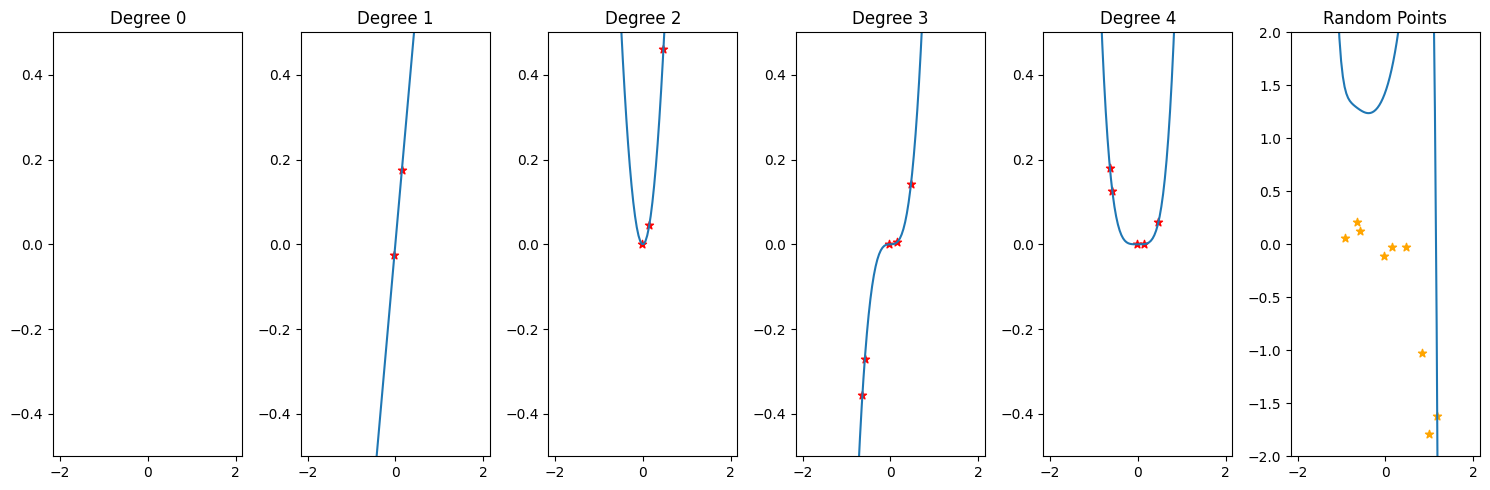

In [217]:
model = np.random.randn(dof)
print("+".join([f"{pi}x^{degree}" for degree, pi in enumerate(model)]))
def loss(model): return 0.5 * (Z @ model  - d) ** 2
print(f"{loss(model).mean()=}")

def make_polynomial_plot(model):
    fig, ax = plt.subplots(1, 6, figsize=(15, 5))
    space = np.linspace(-1.96, 1.96, 100) # 2sigma?
    for degree in range(dof)[:5]:
        pi = model[degree]
        graph = space ** degree * pi
        ax[degree].plot(space, graph)
        ax[degree].scatter(x, pi * x ** degree, marker="*", color="r")
        ax[degree].set_title(f"Degree {degree}")
        ax[degree].set_ylim(-0.5, 0.5)
    ax[5].set_title("Random Points")
    ax[5].plot(space, make_polynomial(space) @ model)
    ax[5].scatter(x, d, marker="*", color="orange")
    ax[5].set_ylim(-2, 2)
    fig.tight_layout()
    return

_ = make_polynomial_plot(model)

13.83032596465002
0.1439752266203987
0.08853936835150458


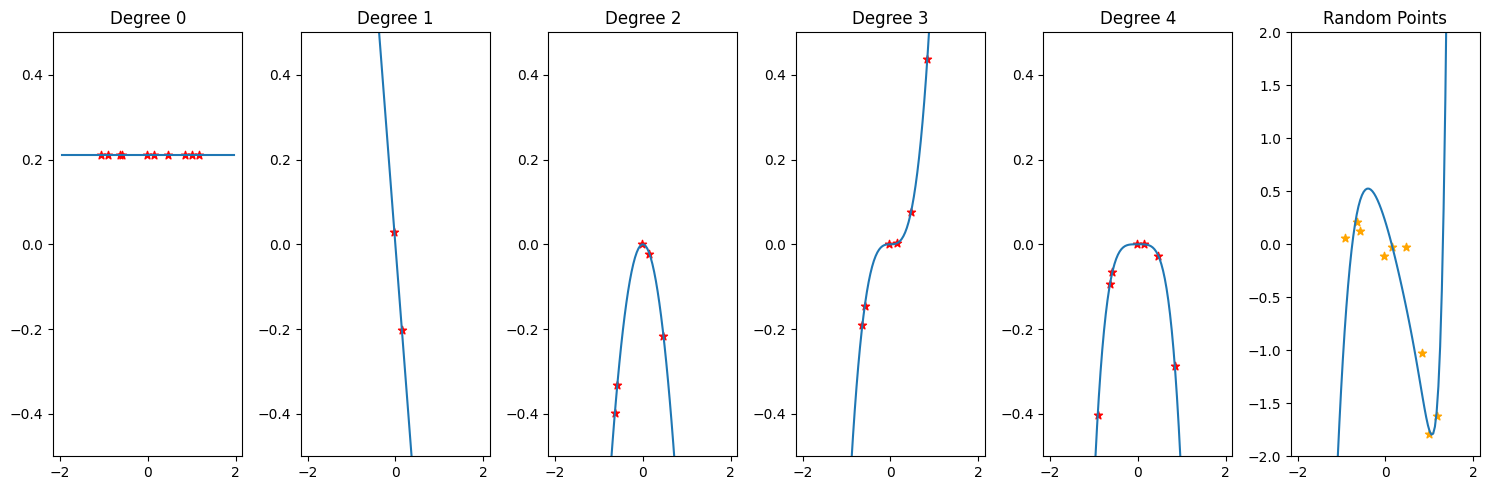

In [220]:
# minimize 1/2(model(Z)-d)^2
# dL/dw => below ((Z @ model - d) * Z).mean(axis=0)
model = np.random.randn(dof)
# x = np.linspace(-0.5, 0.5, 100)
# Z = make_polynomial(x)
# d = Z @ (ps:=np.random.randn(10))
alpha = 0.1
for i in range(30):
    if i % 10 == 0:
        print(loss(model).mean())
    model -= alpha * ((Z @ model - d).reshape(-1, 1) * Z).mean(axis=0)
_ = make_polynomial_plot(model)

**simplify the situation here, for getting insights.**

find the 1 degree of polynomial line crossing (0, 1) (1, 0).

$f(w) = 0.25 \times ((p_0-1)^2+(p_0+p_1-0)^2) = 0.5 \times w^T A w - b^Tw + C$

where, w=coeff; A=[[4, 2], [2, 2]]; b=[2, 0]

In [246]:
x = np.array([0, 1])
y = np.array([1, 0])
Z = make_polynomial(x, _dof=2)
w = np.random.randn(2) # coefficients of polynomial
A = np.array([[2, 1], [1, 1]]) * 2
b = np.array([2, 0])
Ainv = np.linalg.inv(A)
eigval, eigvec = np.linalg.eig(A) # Q \lambda Q^T -> ECA

As we get $\nabla f(w)=Aw-b$, $w^*=A^{-1}b$

In [247]:
w_optimal = Ainv @ b
w_optimal

array([ 1., -1.])

In [250]:
eigvec, eigval

(array([[ 0.85065081, -0.52573111],
        [ 0.52573111,  0.85065081]]),
 array([5.23606798, 0.76393202]))

In [258]:
alpha = 0.1
w0 = w
x0 = eigvec.T @ (w0-w_optimal) # deformation along the eigvector
w1 = w0 - alpha * (A @ w0 - b)
x1 = eigvec.T @ (w1-w_optimal)
w2 = w1 - alpha * (A @ w1 - b)
x2 = eigvec.T @ (w2-w_optimal)

np.allclose(x0 * (1-alpha*eigval), x1), np.allclose(x0 * (1-alpha*eigval)**2, x2)

(True, True)

Text(0.5, 1.0, 'Exponential Shrink Rate')

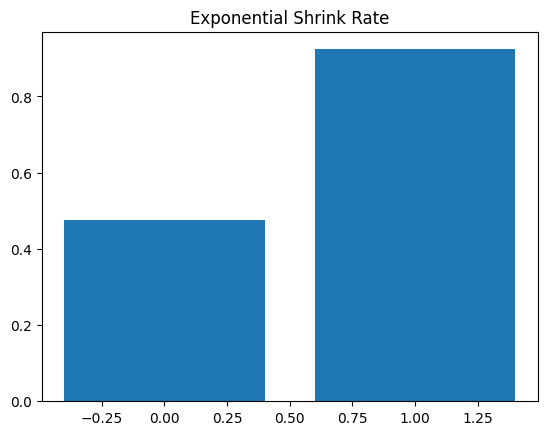

In [262]:
plt.bar(range(2), (1-alpha*eigval))
plt.title("Exponential Shrink Rate")

Text(0.5, 1.0, 'Exponential Shrink Rate, alpha is optimal')

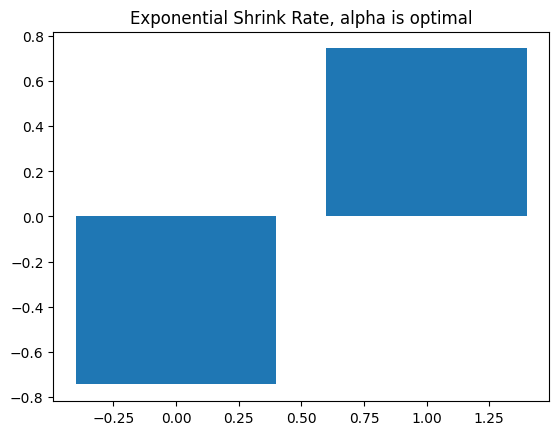

In [265]:
alpha_optimal = 2 / (eigval[0] + eigval[1])
plt.bar(range(2), (1-alpha_optimal*eigval))
plt.title("Exponential Shrink Rate, alpha is optimal")